<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Gradients and Optimizers in QML

_Prepared by Claudia Zendejas-Morales_

Once a supervised objective $\mathcal{L}(\boldsymbol{\theta})$ has been defined, training becomes a question of how to update $\boldsymbol{\theta}$ efficiently and reproducibly. In quantum machine learning, that question is subtle because the objective is evaluated through quantum circuits, while the update itself is carried out by a classical routine.

The discussion below develops that bridge in a formal but practical way. We compare numerical and analytic gradient estimators, quantify the evaluation cost of a gradient step, study the effect of shot noise and seeds on noisy derivatives, and then contrast one gradient-based optimizer with one gradient-free optimizer on the same variational model.


## From an empirical objective to a parameter update

Let the trainable parameter vector be
$$
\boldsymbol{\theta} = (\theta_1,\theta_2,\ldots,\theta_P)
$$
Here $P$ denotes the total number of trainable parameters in the model.

For a mini-batch $B \subseteq \{1,\ldots,M\}$, a supervised empirical objective has the form
$$
\mathcal{L}_B(\boldsymbol{\theta})
=
\frac{1}{|B|}
\sum_{j \in B}
c\!\left(y^j,\hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\right)
$$
Two broad training routes start from that same objective. In a <b>gradient-based</b> route, one first estimates or computes derivatives of $\mathcal{L}_B$. In a <b>gradient-free</b> route, one does not form those derivatives explicitly and instead compares objective values at different candidate parameter vectors.

Gradient-based training asks for the vector
$$
\nabla_{\boldsymbol{\theta}} \mathcal{L}_B(\boldsymbol{\theta})
=
\left(
\frac{\partial \mathcal{L}_B}{\partial \theta_1},
\frac{\partial \mathcal{L}_B}{\partial \theta_2},
\ldots,
\frac{\partial \mathcal{L}_B}{\partial \theta_P}
\right)
$$
and then uses it inside an update rule such as
$$
\theta_m^{(t+1)} = \theta_m^{(t)} - \eta \, g_m^{(t)},
\qquad
g_m^{(t)} \approx \frac{\partial \mathcal{L}_B}{\partial \theta_m}
$$
Here $m \in \{1,\dots,P\}$ indexes the trainable parameter being updated, and $\eta > 0$ is the <b>learning rate</b> or <b>step size</b>, which controls how far the parameter vector moves along the update direction at each iteration.

In full generality, each component may be expanded by the chain rule as
$$
\frac{\partial \mathcal{L}_B}{\partial \theta_m}
=
\frac{1}{|B|}
\sum_{j \in B}
\frac{\partial c}{\partial \hat y_j}
\frac{\partial \hat y_j}{\partial \theta_m},
\qquad
\hat y_j := \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})
$$

The quantity $g_m^{(t)}$ may come from an exact analytic formula, from a numerical approximation, or from a noisy estimate based on finite shots.

A gradient-free route does not build $\nabla_{\boldsymbol{\theta}} \mathcal{L}_B$ explicitly. Instead, it probes objective values at trial points such as $\widetilde{\boldsymbol{\theta}}^{(1)},\dots,\widetilde{\boldsymbol{\theta}}^{(K)}$ and then chooses the next iterate from that information, for example through a rule of the schematic form
$$
\boldsymbol{\theta}^{(t+1)}
=
\Phi_t\!\left(
\widetilde{\boldsymbol{\theta}}^{(1)},\dots,\widetilde{\boldsymbol{\theta}}^{(K)};
\mathcal{L}_B\!\left(\widetilde{\boldsymbol{\theta}}^{(1)}\right),\dots,\mathcal{L}_B\!\left(\widetilde{\boldsymbol{\theta}}^{(K)}\right)
\right),
$$
where $\Phi_t$ denotes the internal update rule of the optimizer at iteration $t$.

So the word <b>optimizer</b> is the more general term: it is the classical procedure that proposes the next parameter vector. <b>Gradient-based</b> and <b>gradient-free</b> describe what kind of information that optimizer uses in order to make the update.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/optimizers-in-qml.png" alt="Gradient-based and gradient-free optimizers in a hybrid QML workflow" width="900"/>
</p>

In both routes the optimizer lives on the classical side of the loop. What changes is the information it uses to propose the next parameter vector: explicit gradient information in the gradient-based case, or only objective values in the gradient-free case.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Gradient-based versus gradient-free</b><br>
A <b>gradient-based</b> route updates the parameters using explicit derivative information, so it needs some way of obtaining or estimating components such as $\frac{\partial \mathcal{L}_B}{\partial \theta_m}$. In practice, that usually means introducing a gradient estimator or an analytic differentiation rule. A <b>gradient-free</b> route does not build those derivatives explicitly and instead lets the optimizer compare objective values at different trial parameter vectors. In both cases, the <b>optimizer</b> is the more general classical procedure that proposes the next iterate.
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml
from scipy.optimize import minimize
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=4, suppress=True)


## A tiny exact model for gradient experiments

To make the role of differentiation easy to inspect, we use a small two-qubit variational model and evaluate it exactly with a statevector simulator. For a sample $\vec{x}^{\,j} = (x_1^{\,j}, x_2^{\,j})$, the circuit prepares
$$
|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle = U_F(\vec{x}^{\,j}) |0\rangle^{\otimes 2},
\qquad
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle
=
U_A(\boldsymbol{\theta}) |\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle
$$
In the more general notation already used earlier in the module, one may first define a measured feature vector
$$
\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\bigl(\langle O_1 \rangle, \langle O_2 \rangle, \dots, \langle O_R \rangle\bigr)
$$
The present example uses the scalar-observable special case
$$
f_O(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$
with $O = Z_0$, so we write
$$
s(\vec{x}^{\,j}, \boldsymbol{\theta})
=
f_O(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\bra{\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})} Z_0 \ket{\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})}
$$
The probability used by binary cross-entropy is then
$$
p(\vec{x}^{\,j}, \boldsymbol{\theta}) = \frac{1 + s(\vec{x}^{\,j}, \boldsymbol{\theta})}{2},
\qquad
\hat y(\vec{x}^{\,j}, \boldsymbol{\theta}) = p(\vec{x}^{\,j}, \boldsymbol{\theta})
$$
For a batch $B$, the per-sample and aggregated supervised quantities are
$$
c_{\mathrm{BCE}}\!\left(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\right)
=
- y^j \log p_j - (1-y^j) \log(1-p_j),
\qquad
p_j := p(\vec{x}^{\,j}, \boldsymbol{\theta})
$$
$$
\mathcal{L}_{B,\mathrm{BCE}}(\boldsymbol{\theta})
=
\frac{1}{|B|}
\sum_{j \in B}
c_{\mathrm{BCE}}\!\left(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\right)
$$


The next code cell implements exactly the ingredients just defined: a two-qubit feature map $U_F(\vec{x}^{\,j})$, a small ansatz $U_A(\boldsymbol{\theta})$, the scalar readout $s(\vec{x}^{\,j}, \boldsymbol{\theta}) = f_O(\vec{x}^{\,j}, \boldsymbol{\theta})$, the probability map $p = (1+s)/2$, and the corresponding binary cross-entropy objective on a batch. It also defines reusable helper functions for finite differences, parameter shift, shot-based estimates, and simple evaluation-cost accounting, since those will be reused throughout the rest of the notebook.


In [2]:
ANALYTIC_DEVICE = qml.device("default.qubit", wires=2)


def variational_circuit(x, weights):
    qml.RY(float(x[0]), wires=0)
    qml.RY(float(x[1]), wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(float(weights[0]), wires=0)
    qml.RY(float(weights[1]), wires=1)
    qml.CNOT(wires=[1, 0])
    qml.RY(float(weights[2]), wires=0)
    qml.RY(float(weights[3]), wires=1)


@qml.qnode(ANALYTIC_DEVICE)
def analytic_score_qnode(x, weights):
    variational_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))


def exact_score(x, weights):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return float(analytic_score_qnode(x, weights))


def batch_scores(samples, weights):
    return np.array([exact_score(x, weights) for x in samples], dtype=float)


def probabilities_from_scores(scores, eps=1e-9):
    probabilities = (1.0 + np.asarray(scores, dtype=float)) / 2.0
    return np.clip(probabilities, eps, 1.0 - eps)


def binary_cross_entropy_per_sample(labels, probabilities):
    labels = np.asarray(labels, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return -(labels * np.log(probabilities) + (1.0 - labels) * np.log(1.0 - probabilities))


def mean_binary_cross_entropy(samples, labels, weights):
    scores = batch_scores(samples, weights)
    probabilities = probabilities_from_scores(scores)
    return float(np.mean(binary_cross_entropy_per_sample(labels, probabilities)))


def bce_score_derivative(labels, probabilities):
    labels = np.asarray(labels, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return 0.5 * (-labels / probabilities + (1.0 - labels) / (1.0 - probabilities))


def forward_difference_gradient(samples, labels, weights, eps):
    weights = np.asarray(weights, dtype=float)
    gradient = np.zeros_like(weights)
    baseline = mean_binary_cross_entropy(samples, labels, weights)
    for m in range(len(weights)):
        shifted = weights.copy()
        shifted[m] += eps
        gradient[m] = (mean_binary_cross_entropy(samples, labels, shifted) - baseline) / eps
    return gradient


def central_difference_gradient(samples, labels, weights, eps):
    weights = np.asarray(weights, dtype=float)
    gradient = np.zeros_like(weights)
    for m in range(len(weights)):
        plus = weights.copy()
        minus = weights.copy()
        plus[m] += eps
        minus[m] -= eps
        gradient[m] = (
            mean_binary_cross_entropy(samples, labels, plus)
            - mean_binary_cross_entropy(samples, labels, minus)
        ) / (2.0 * eps)
    return gradient


def parameter_shift_score_jacobian(samples, weights, shift=np.pi / 2):
    samples = np.asarray(samples, dtype=float)
    weights = np.asarray(weights, dtype=float)
    jacobian = np.zeros((len(samples), len(weights)))
    for m in range(len(weights)):
        plus = weights.copy()
        minus = weights.copy()
        plus[m] += shift
        minus[m] -= shift
        s_plus = batch_scores(samples, plus)
        s_minus = batch_scores(samples, minus)
        jacobian[:, m] = 0.5 * (s_plus - s_minus)
    return jacobian


def parameter_shift_bce_gradient(samples, labels, weights):
    scores = batch_scores(samples, weights)
    probabilities = probabilities_from_scores(scores)
    score_jacobian = parameter_shift_score_jacobian(samples, weights)
    sample_derivatives = bce_score_derivative(labels, probabilities)
    return score_jacobian.T @ sample_derivatives / len(samples)


def make_shot_score_qnode(shots, seed):
    shot_device = qml.device("default.qubit", wires=2, seed=int(seed))

    @qml.qnode(shot_device)
    def shot_score_qnode(x, weights):
        variational_circuit(x, weights)
        return qml.expval(qml.PauliZ(0))

    return qml.set_shots(shot_score_qnode, shots=int(shots))


def shot_based_z_score(x, weights, shots, rng):
    seed = int(rng.integers(0, 2**31 - 1))
    shot_score_qnode = make_shot_score_qnode(shots=shots, seed=seed)
    return float(shot_score_qnode(np.asarray(x, dtype=float), np.asarray(weights, dtype=float)))


def parameter_shift_shot_score_derivative(x, weights, param_index, shots, rng, shift=np.pi / 2):
    plus = np.asarray(weights, dtype=float).copy()
    minus = np.asarray(weights, dtype=float).copy()
    plus[param_index] += shift
    minus[param_index] -= shift
    s_plus = shot_based_z_score(x, plus, shots=shots, rng=rng)
    s_minus = shot_based_z_score(x, minus, shots=shots, rng=rng)
    return 0.5 * (s_plus - s_minus)


def per_step_score_evaluations(num_params, batch_size, mode):
    if mode == "forward":
        return (num_params + 1) * batch_size
    if mode in {"central", "shift"}:
        return 2 * num_params * batch_size
    raise ValueError(f"Unknown mode: {mode}")


def epoch_score_evaluations(num_params, n_train, batch_size, mode):
    full_steps = n_train // batch_size
    remainder = n_train % batch_size
    total = full_steps * per_step_score_evaluations(num_params, batch_size, mode)
    if remainder:
        total += per_step_score_evaluations(num_params, remainder, mode)
    return total


def training_shot_budget(num_params, n_train, batch_size, mode, shots, epochs):
    return epochs * epoch_score_evaluations(num_params, n_train, batch_size, mode) * shots


samples_grad = np.array([
    [0.15, 0.20],
    [0.40, 0.85],
    [0.90, 0.30],
    [1.05, 0.95],
    [1.35, 0.50],
], dtype=float)
y_grad = np.array([0, 1, 1, 0, 1], dtype=int)
weights_ref = np.array([0.40, -0.70, 0.80, 0.15], dtype=float)


## Finite differences as a numerical baseline

A first way to approximate the gradient is to perturb one parameter at a time and observe how the objective changes. For the $m$-th component, the forward and centered finite-difference formulas are
$$
\frac{\partial \mathcal{L}_B}{\partial \theta_m}
\approx
\frac{\mathcal{L}_B(\boldsymbol{\theta} + \varepsilon \, \mathbf{e}_m) - \mathcal{L}_B(\boldsymbol{\theta})}{\varepsilon}
$$
$$
\frac{\partial \mathcal{L}_B}{\partial \theta_m}
\approx
\frac{\mathcal{L}_B(\boldsymbol{\theta} + \varepsilon \, \mathbf{e}_m) - \mathcal{L}_B(\boldsymbol{\theta} - \varepsilon \, \mathbf{e}_m)}{2 \varepsilon}
$$
where $\mathbf{e}_m$ is the unit vector along parameter $\theta_m$ and $\varepsilon > 0$ is a small step size.

These approximations are simple and general, but they are not exact. If $\varepsilon$ is too large, truncation error dominates. If $\varepsilon$ is too small, numerical cancellation can dominate. The first example below makes that tradeoff visible on a fixed batch.


parameter-shift reference: [ 0.119  -0.0756  0.1042 -0.    ]
eps=1e-01
  forward: [ 0.1559 -0.0665  0.1393  0.    ]
  central: [ 0.1188 -0.0763  0.1041  0.    ]
  ||forward - shift||_2 = 5.172959e-02
  ||central - shift||_2 = 7.109050e-04
eps=1e-02
  forward: [ 0.1227 -0.0747  0.1077 -0.    ]
  central: [ 0.119  -0.0756  0.1042 -0.    ]
  ||forward - shift||_2 = 5.197595e-03
  ||central - shift||_2 = 7.116187e-06
eps=1e-03
  forward: [ 0.1194 -0.0755  0.1045  0.    ]
  central: [ 0.119  -0.0756  0.1042 -0.    ]
  ||forward - shift||_2 = 5.200375e-04
  ||central - shift||_2 = 7.116253e-08
eps=1e-04
  forward: [ 0.1191 -0.0756  0.1042  0.    ]
  central: [ 0.119  -0.0756  0.1042  0.    ]
  ||forward - shift||_2 = 5.200657e-05
  ||central - shift||_2 = 7.116650e-10


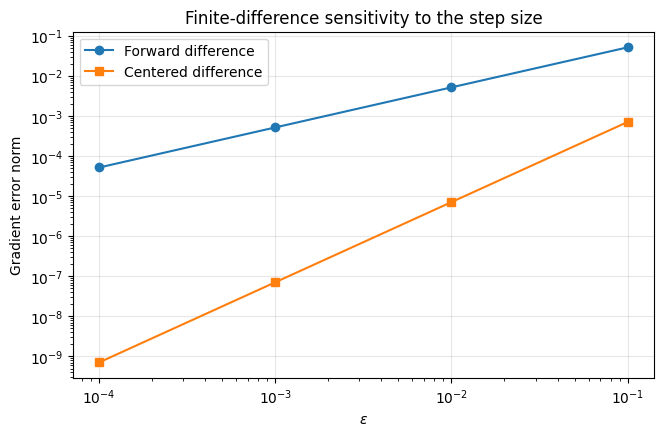

In [3]:
eps_values = np.array([1e-1, 1e-2, 1e-3, 1e-4], dtype=float)
grad_shift_ref = parameter_shift_bce_gradient(samples_grad, y_grad, weights_ref)

forward_errors = []
central_errors = []

print("parameter-shift reference:", grad_shift_ref)
for eps in eps_values:
    grad_forward = forward_difference_gradient(samples_grad, y_grad, weights_ref, eps)
    grad_central = central_difference_gradient(samples_grad, y_grad, weights_ref, eps)
    forward_error = np.linalg.norm(grad_forward - grad_shift_ref)
    central_error = np.linalg.norm(grad_central - grad_shift_ref)
    forward_errors.append(forward_error)
    central_errors.append(central_error)
    print(f"eps={eps:1.0e}")
    print("  forward:", grad_forward)
    print("  central:", grad_central)
    print(f"  ||forward - shift||_2 = {forward_error:.6e}")
    print(f"  ||central - shift||_2 = {central_error:.6e}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_values, forward_errors, marker="o", label="Forward difference")
ax.loglog(eps_values, central_errors, marker="s", label="Centered difference")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel("Gradient error norm")
ax.set_title("Finite-difference sensitivity to the step size")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


The printed gradients and the log-log plot should show the usual pattern: centered differences are typically more accurate than forward differences at the same $\varepsilon$, but neither method is exact. The point of the example is not to identify one universal best step size, but to see that finite differences introduce a tuning problem of their own. That tuning cost becomes more noticeable as the number of trainable parameters grows.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Forward versus centered finite differences</b><br>
A <b>forward difference</b> compares the objective at the current parameter vector with the objective at one <b>forward-shifted</b> point, so it uses an asymmetric local view of the slope. A <b>centered difference</b> compares one forward-shifted point with one backward-shifted point, so it uses information from <b>both sides</b> of the current parameter value. This symmetric construction is the main reason centered differences often approximate the local slope more accurately, although they also require more objective evaluations than the forward formula. For a more detailed discussion of finite-difference approximations, including forward and centered formulas, see <a href="https://ocw.mit.edu/courses/18-s096-matrix-calculus-for-machine-learning-and-beyond-january-iap-2023/mit18_s096iap23_lec04.pdf">these MIT OpenCourseWare notes on finite-difference approximations</a>.
</div>


**Implementation note.** In PennyLane, finite differences are exposed through <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.gradients.finite_diff.html"><code>qml.gradients.finite_diff</code></a>, and the same strategy can also be registered at QNode level with `diff_method="finite-diff"`. The corresponding Qiskit Algorithms class is <a href="https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.gradients.FiniteDiffEstimatorGradient.html"><code>FiniteDiffEstimatorGradient</code></a>, which allows `method="central"`, `"forward"`, or `"backward"`.


## The parameter-shift rule in its simplest common form

For many variational gates of the form
$$
U_m(\theta_m) = e^{-i \theta_m G_m / 2}
$$
where the generator $G_m$ has two eigenvalues $\pm 1$, the derivative of a scalar expectation value can be written exactly as
$$
\frac{\partial s(\vec{x}^{\,j}, \boldsymbol{\theta})}{\partial \theta_m}
=
\frac{
s(\vec{x}^{\,j}, \boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_m)
-
s(\vec{x}^{\,j}, \boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_m)
}{2}
$$
Equivalently, in the scalar-observable notation of the previous section,
$$
\frac{\partial f_O(\vec{x}^{\,j}, \boldsymbol{\theta})}{\partial \theta_m}
=
\frac{
f_O(\vec{x}^{\,j}, \boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_m)
-
f_O(\vec{x}^{\,j}, \boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_m)
}{2}
$$
Since binary cross-entropy depends on the score through
$$
p_j = \frac{1+s_j}{2},
\qquad
s_j := s(\vec{x}^{\,j}, \boldsymbol{\theta})
$$
the full chain rule takes the form
$$
\frac{\partial \mathcal{L}_{B,\mathrm{BCE}}}{\partial \theta_m}
=
\frac{1}{|B|}
\sum_{j \in B}
\frac{\partial c_{\mathrm{BCE}}}{\partial p_j}
\frac{\partial p_j}{\partial s_j}
\frac{\partial s_j}{\partial \theta_m}
$$
with
$$
\frac{\partial c_{\mathrm{BCE}}}{\partial p_j}
=
-\frac{y^j}{p_j} + \frac{1-y^j}{1-p_j},
\qquad
\frac{\partial p_j}{\partial s_j} = \frac{1}{2}
$$
Hence
$$
\frac{\partial \mathcal{L}_{B,\mathrm{BCE}}}{\partial \theta_m}
=
\frac{1}{|B|}
\sum_{j \in B}
\frac{1}{2}
\left(
-\frac{y^j}{p_j}
+
\frac{1-y^j}{1-p_j}
\right)
\frac{\partial s_j}{\partial \theta_m}
$$


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>This is the simplest common parameter-shift case</b><br>
The two-evaluation formula with shifts $\pm \pi/2$ is exact for many one-parameter gates whose generator has two eigenvalues $\pm 1$, which includes the usual Pauli-generated rotations such as $R_x$, $R_y$, and $R_z$. More general parameter-shift rules also exist for other gate families, but they may require different shifts, extra coefficients, or more than two circuit evaluations. For a more general treatment, including generators with more than two eigenvalues, see <a href="https://arxiv.org/abs/2107.12390">Wierichs et al., <i>General parameter-shift rules for quantum gradients</i></a>.
</div>


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/gradient-estimators-overview.png" alt="Comparison between finite differences and the parameter-shift rule" width="900"/>
</p>

Finite differences and parameter shift may both require many circuit evaluations, but they answer different questions. Finite differences are generic numerical approximations, whereas parameter shift can be an exact derivative formula for the score when the gate generators satisfy the required spectral condition.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Exact on the simulator does not mean exact on hardware</b><br>
In the next cell, parameter shift is exact because the circuit is evaluated with exact statevectors and the trainable gates are simple $R_Y$ rotations. On hardware, the same formula still holds at the expectation-value level, but the measured estimates inherit shot noise and hardware noise. Exact differentiation and noiseless evaluation are not the same statement.
</div>


**Implementation note.** In PennyLane, the parameter-shift rule is available directly through <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.gradients.param_shift.html"><code>qml.gradients.param_shift</code></a>, and the same rule can be activated on a QNode with `diff_method="parameter-shift"`. The corresponding Qiskit Algorithms class is <a href="https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.gradients.ParamShiftEstimatorGradient.html"><code>ParamShiftEstimatorGradient</code></a>.


forward difference: [ 0.1227 -0.0747  0.1077 -0.    ]
centered difference: [ 0.119  -0.0756  0.1042 -0.    ]
parameter shift: [ 0.119  -0.0756  0.1042 -0.    ]
forward error norm: 0.005197595455756214
centered error norm: 7.1161873714009614e-06


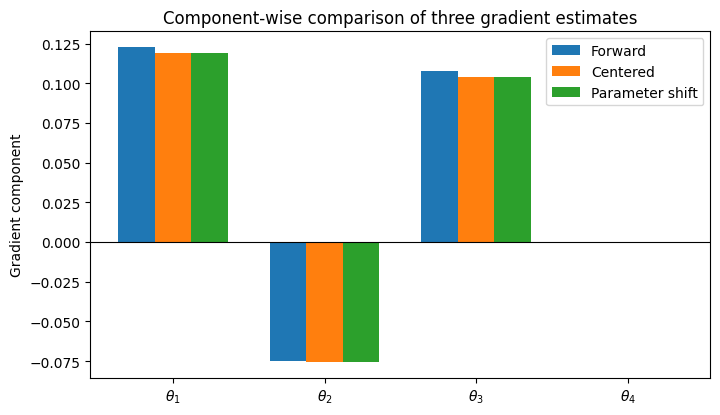

In [4]:
eps_compare = 1e-2
grad_forward = forward_difference_gradient(samples_grad, y_grad, weights_ref, eps_compare)
grad_central = central_difference_gradient(samples_grad, y_grad, weights_ref, eps_compare)
grad_shift = parameter_shift_bce_gradient(samples_grad, y_grad, weights_ref)

print("forward difference:", grad_forward)
print("centered difference:", grad_central)
print("parameter shift:", grad_shift)
print("forward error norm:", np.linalg.norm(grad_forward - grad_shift))
print("centered error norm:", np.linalg.norm(grad_central - grad_shift))

labels = [rf"$\theta_{{{m+1}}}$" for m in range(len(weights_ref))]
x_axis = np.arange(len(labels))
width = 0.24

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.bar(x_axis - width, grad_forward, width=width, label="Forward")
ax.bar(x_axis, grad_central, width=width, label="Centered")
ax.bar(x_axis + width, grad_shift, width=width, label="Parameter shift")
ax.set_xticks(x_axis)
ax.set_xticklabels(labels)
ax.set_ylabel("Gradient component")
ax.set_title("Component-wise comparison of three gradient estimates")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.legend()
plt.show()


The bar plot makes the comparison more local: it is possible for two estimators to agree well on some components and poorly on others. Parameter shift is especially attractive in QML because it avoids choosing an $\varepsilon$ parameter and yields the exact score derivative for a large and useful gate family. The price is still a linear growth in circuit evaluations with the number of trainable parameters.


### Task 1 (coding): How sensitive is a numerical gradient to the choice of $\varepsilon$?

Reuse the same helper functions, but now work on the batch and parameter vector below:

```python
samples_task1 = np.array([
    [0.10, 0.35],
    [0.55, 0.95],
    [0.80, 0.20],
    [1.15, 0.75],
    [1.45, 0.45],
    [1.70, 1.10],
])
y_task1 = np.array([0, 1, 1, 0, 1, 0])
weights_task1 = np.array([-0.25, 0.60, 0.15, -0.45])
eps_grid = np.array([1e-1, 3e-2, 1e-2, 3e-3, 1e-3])
```

Compute the parameter-shift reference gradient and then evaluate forward and centered finite differences for every value in `eps_grid`. Determine the best $\varepsilon$ for each numerical estimator, report the corresponding error norms, and identify which parameter component remains the least accurate for the forward-difference estimate even at its best $\varepsilon$. Finally, summarize in 4 to 6 sentences what this experiment says about the stability of numerical differentiation in QML.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="02-gradients-and-optimizers-in-qml-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [5]:
# Task 1 starter
samples_task1 = np.array([
    [0.10, 0.35],
    [0.55, 0.95],
    [0.80, 0.20],
    [1.15, 0.75],
    [1.45, 0.45],
    [1.70, 1.10],
])
y_task1 = np.array([0, 1, 1, 0, 1, 0])
weights_task1 = np.array([-0.25, 0.60, 0.15, -0.45])
eps_grid = np.array([1e-1, 3e-2, 1e-2, 3e-3, 1e-3])

# TODO:
# 1. compute the parameter-shift reference gradient
# 2. evaluate forward and centered finite differences on the whole epsilon grid
# 3. store the error norm for each epsilon and each estimator
# 4. identify the best epsilon for forward and for centered differences
# 5. identify the parameter component with the largest forward-error contribution
# 6. summarize what the experiment says about numerical differentiation


## How many circuit evaluations does one gradient step cost?

Let $P$ be the number of trainable parameters and let $|B|$ be the batch size. If the objective is evaluated sample by sample, then one gradient step requires approximately
$$
N_{\mathrm{fwd}} = (P+1)|B|,
\qquad
N_{\mathrm{ctr}} = 2P|B|,
\qquad
N_{\mathrm{shift}} = 2P|B|
$$
score evaluations for forward differences, centered differences, and parameter shift, respectively. When each score estimate itself uses `shots` measurements, the shot budget scales by an additional multiplicative factor.

Batching changes the number of parameter updates per epoch, while the total evaluation cost per epoch remains proportional to the number of samples seen during that epoch. The next example makes that accounting explicit.


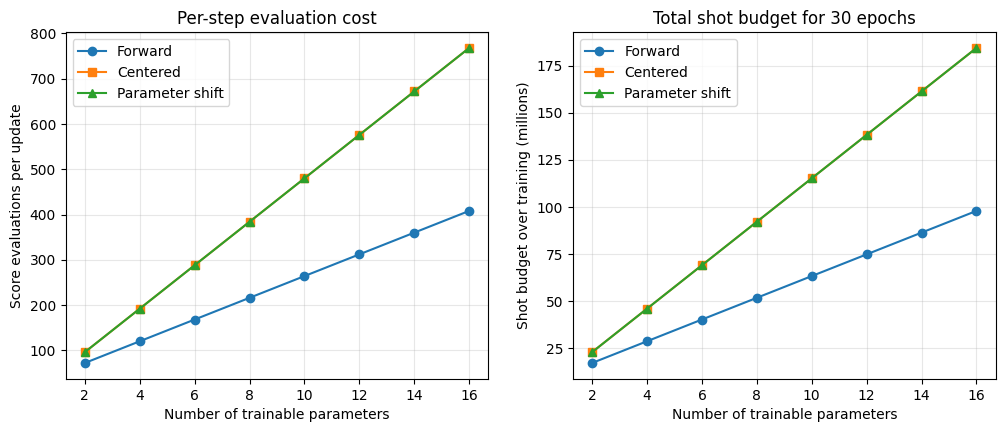

In [6]:
param_counts = np.arange(2, 18, 2)
batch_size = 24
n_train = 96
shots = 2000
epochs = 30

forward_per_step = [per_step_score_evaluations(P, batch_size, "forward") for P in param_counts]
central_per_step = [per_step_score_evaluations(P, batch_size, "central") for P in param_counts]
shift_per_step = [per_step_score_evaluations(P, batch_size, "shift") for P in param_counts]

forward_budget = [training_shot_budget(P, n_train, batch_size, "forward", shots, epochs) for P in param_counts]
central_budget = [training_shot_budget(P, n_train, batch_size, "central", shots, epochs) for P in param_counts]
shift_budget = [training_shot_budget(P, n_train, batch_size, "shift", shots, epochs) for P in param_counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(param_counts, forward_per_step, marker="o", label="Forward")
axes[0].plot(param_counts, central_per_step, marker="s", label="Centered")
axes[0].plot(param_counts, shift_per_step, marker="^", label="Parameter shift")
axes[0].set_xlabel("Number of trainable parameters")
axes[0].set_ylabel("Score evaluations per update")
axes[0].set_title("Per-step evaluation cost")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(param_counts, np.array(forward_budget) / 1e6, marker="o", label="Forward")
axes[1].plot(param_counts, np.array(central_budget) / 1e6, marker="s", label="Centered")
axes[1].plot(param_counts, np.array(shift_budget) / 1e6, marker="^", label="Parameter shift")
axes[1].set_xlabel("Number of trainable parameters")
axes[1].set_ylabel("Shot budget over training (millions)")
axes[1].set_title("Total shot budget for 30 epochs")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


The left panel highlights the linear scaling with $P$, while the right panel shows how quickly that scaling turns into a shot-budget question once repeated training epochs are taken into account. For small exact-simulation examples, these costs remain modest; for hardware experiments, they become one of the main reasons to think carefully about ansatz size, batch size, and optimizer choice.


### Task 2 (coding): Which training plans fit inside a fixed shot budget?

Reuse the cost-accounting helpers and study the configurations below:

```python
param_counts = [4, 10, 20]
batch_sizes = [96, 24]
modes = ["forward", "central", "shift"]
shot_values = [500, 2000]
shot_cap = 2.0e7
target_epochs = 30
n_train = 96
```

Build a table that reports the per-step score evaluations, the total shot budget for `target_epochs`, and the maximum number of full epochs allowed by `shot_cap` for every configuration. Then identify which configurations can afford at least 30 epochs, and among those feasible cases select the one that gives the largest number of parameter updates per epoch. End with a short discussion of why a budget-constrained comparison should not mix optimizers or estimators that consume dramatically different resources.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="02-gradients-and-optimizers-in-qml-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [7]:
# Task 2 starter
param_counts = [4, 10, 20]
batch_sizes = [96, 24]
modes = ["forward", "central", "shift"]
shot_values = [500, 2000]
shot_cap = 2.0e7
target_epochs = 30
n_train = 96

# TODO:
# 1. build one row per configuration with per-step, total-budget, and max-epoch information
# 2. collect the rows in a structure that is easy to sort or print
# 3. identify the configurations that can afford at least 30 epochs
# 4. among the feasible ones, determine which gives the largest number of updates per epoch
# 5. summarize why fixed-budget comparisons should track resource usage explicitly


## Shot-based gradients, batching, and seeds

On hardware, the expectation value $s(\vec{x}^{\,j}, \boldsymbol{\theta})$ is estimated from finite shots, so its derivative estimate inherits sampling noise. For a single parameter component, a shot-based parameter-shift estimate can be written as
$$
\widehat{\frac{\partial s}{\partial \theta_m}}
=
\frac{
\widehat{s}\!\left(\vec{x}^{\,j}, \boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_m\right)
-
\widehat{s}\!\left(\vec{x}^{\,j}, \boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_m\right)
}{2}
$$
where each hatted score comes from a finite-shot estimate. Mini-batches add a second source of variability because the samples included in $B$ can change from one update to the next.

The next experiment isolates the shot-noise part by fixing one sample and one parameter component, and then repeating the same estimate with increasing shot counts.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Same formula shape, different meaning</b><br>
The shot-based expression has the <b>same algebraic form</b> as the exact parameter-shift rule shown earlier, but the meaning is different because the scores now carry hats. The unhatted formula uses exact expectation values $s(\vec{x}^{\,j}, \boldsymbol{\theta})$, so under the stated assumptions it gives the exact derivative of the score. The hatted formula replaces those expectation values by finite-shot estimates $\widehat{s}(\vec{x}^{\,j}, \boldsymbol{\theta})$, so it defines a <b>noisy estimator</b> of the derivative rather than the exact derivative itself.
</div>


shots= 100  mean=-0.837000  std= 0.032187
shots= 500  mean=-0.832200  std= 0.015052
shots=2000  mean=-0.830637  std= 0.008357


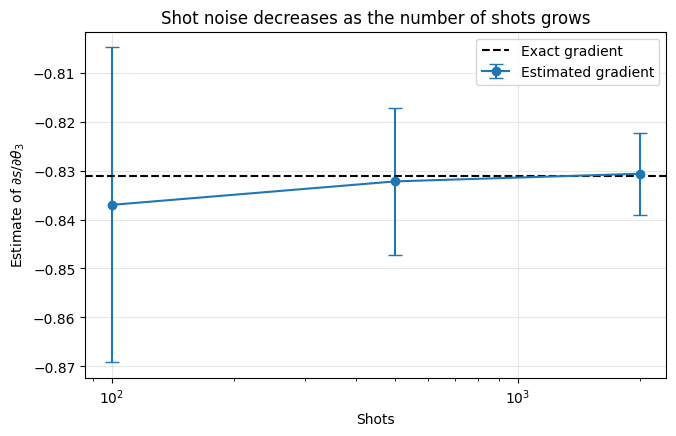

In [8]:
x_noise = np.array([0.65, 0.35], dtype=float)
weights_noise = np.array([0.40, -0.70, 0.80, 0.15], dtype=float)
param_index = 2
shot_values = [100, 500, 2000]
num_repeats = 40

exact_gradient = 0.5 * (
    exact_score(x_noise, weights_noise + np.array([0.0, 0.0, np.pi / 2, 0.0]))
    - exact_score(x_noise, weights_noise - np.array([0.0, 0.0, np.pi / 2, 0.0]))
)

shot_means = []
shot_stds = []
for shots in shot_values:
    estimates = []
    for seed in range(num_repeats):
        rng = np.random.default_rng(seed)
        estimate = parameter_shift_shot_score_derivative(
            x_noise, weights_noise, param_index=param_index, shots=shots, rng=rng
        )
        estimates.append(estimate)
    estimates = np.array(estimates, dtype=float)
    shot_means.append(np.mean(estimates))
    shot_stds.append(np.std(estimates))
    print(f"shots={shots:4d}  mean={np.mean(estimates): .6f}  std={np.std(estimates): .6f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(shot_values, shot_means, yerr=shot_stds, marker="o", capsize=5, label="Estimated gradient")
ax.axhline(exact_gradient, color="black", linestyle="--", label="Exact gradient")
ax.set_xscale("log")
ax.set_xlabel("Shots")
ax.set_ylabel(r"Estimate of $\partial s / \partial \theta_3$")
ax.set_title("Shot noise decreases as the number of shots grows")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


The output shows a familiar pattern: the mean estimate stays close to the exact derivative, while the spread decreases as the number of shots grows. That does not mean high-shot training is automatically better, because larger shot counts also make every update more expensive. In practice, reproducible benchmarking requires fixing the random seed for data shuffling and also controlling the seed used for shot sampling whenever the simulator allows it.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Fix seeds when comparing noisy gradients</b><br>
If two experiments use different mini-batch orders or different shot-sampling seeds, then a difference in performance may come from randomness rather than from the optimizer or estimator itself. Reproducibility in QML means controlling classical randomness and quantum sampling randomness together.
</div>


## Adam and COBYLA on the same variational model

Adam is a gradient-based optimizer that works with the gradient vector at iteration $t$,
$$
\boldsymbol{g}^{(t)} = \nabla_{\boldsymbol{\theta}} \mathcal{L}_B\!\left(\boldsymbol{\theta}^{(t)}\right)
$$
and maintains running estimates of its first and second moments:
$$
\boldsymbol{m}^{(t)} = \beta_1 \boldsymbol{m}^{(t-1)} + (1-\beta_1) \boldsymbol{g}^{(t)},
\qquad
\boldsymbol{v}^{(t)} = \beta_2 \boldsymbol{v}^{(t-1)} + (1-\beta_2) \boldsymbol{g}^{(t)\odot 2}
$$
where $\boldsymbol{g}^{(t)\odot 2}$ denotes the component-wise square of the gradient vector. After bias correction,
$$
\widehat{\boldsymbol{m}}^{(t)} = \frac{\boldsymbol{m}^{(t)}}{1-\beta_1^{t}},
\qquad
\widehat{\boldsymbol{v}}^{(t)} = \frac{\boldsymbol{v}^{(t)}}{1-\beta_2^{t}}
$$
the parameter update is written as
$$
\boldsymbol{\theta}^{(t+1)}
=
\boldsymbol{\theta}^{(t)}
-
\eta
\frac{\widehat{\boldsymbol{m}}^{(t)}}{\sqrt{\widehat{\boldsymbol{v}}^{(t)}} + \epsilon}
$$
Here $\boldsymbol{m}^{(t)}$ is the <b>first-moment estimate</b> of the gradient, $\boldsymbol{v}^{(t)}$ is the <b>second-moment estimate</b>, and $\boldsymbol{g}^{(t)}$ is the gradient vector itself. The coefficients $\beta_1$ and $\beta_2$ are decay parameters that control how strongly Adam remembers past gradient information in those running averages.

COBYLA, by contrast, is a derivative-free constrained optimizer that replaces the objective locally by a linear approximation. Schematically, near the current iterate $\boldsymbol{\theta}^{(t)}$, one writes a local model of the form
$$
\widetilde{\mathcal{L}}^{(t)}(\boldsymbol{\theta})
=
a^{(t)} + \boldsymbol{b}^{(t)\top}(\boldsymbol{\theta}-\boldsymbol{\theta}^{(t)})
$$
and then chooses the next trial point by minimizing that local model inside a trust region,
$$
\boldsymbol{\theta}^{(t+1)}
\approx
\arg\min_{\boldsymbol{\theta}}
\widetilde{\mathcal{L}}^{(t)}(\boldsymbol{\theta})
\qquad
\text{subject to}
\qquad
\lVert \boldsymbol{\theta}-\boldsymbol{\theta}^{(t)} \rVert \le \rho^{(t)}
$$
with analogous local linear approximations for any inequality constraints when they are present. Here $\rho^{(t)}$ is the current trust-region radius. In a QML workflow, the important point is that COBYLA uses only objective values to build these local models; it does not require explicit gradient vectors.

Both approaches can be useful. Adam is usually more sample-efficient when reliable gradients are available; COBYLA can still make progress when gradients are noisy, expensive, or inconvenient to estimate.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Gradient-free does not mean cost-free</b><br>
COBYLA avoids explicit derivatives, but it still consumes many objective evaluations. In hardware-oriented QML, that means a derivative-free method can still be very expensive if every objective call requires many shots.
</div>


**Implementation note.** In the code below, the quantum objective is built with PennyLane, while the gradient-based Adam loop is written explicitly and the derivative-free COBYLA optimizer is accessed through SciPy. PennyLane also provides a built-in gradient-based optimizer, <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.AdamOptimizer.html"><code>qml.AdamOptimizer</code></a>, and a shot-aware option, <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.ShotAdaptiveOptimizer.html"><code>qml.ShotAdaptiveOptimizer</code></a>. On the Qiskit side, dedicated APIs are available for both <a href="https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.optimizers.ADAM.html"><code>ADAM</code></a> and <a href="https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.optimizers.COBYLA.html"><code>COBYLA</code></a>.


In [9]:
def predict_probabilities(samples, weights):
    scores = batch_scores(samples, weights)
    return probabilities_from_scores(scores)


def predict_labels(samples, weights, threshold=0.5):
    probabilities = predict_probabilities(samples, weights)
    return (probabilities >= threshold).astype(int)


def evaluate_classifier(samples, labels, weights):
    probabilities = predict_probabilities(samples, weights)
    predictions = (probabilities >= 0.5).astype(int)
    bce = float(np.mean(binary_cross_entropy_per_sample(labels, probabilities)))
    accuracy = float(accuracy_score(labels, predictions))
    return {"bce": bce, "accuracy": accuracy}


def prepare_binary_dataset(seed=12):
    X, y = make_moons(n_samples=96, noise=0.16, random_state=seed)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.40, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    return X_train, X_val, X_test, y_train, y_val, y_test


def adam_train(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights,
    epochs=35,
    batch_size=12,
    learning_rate=0.08,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    seed=23,
):
    rng = np.random.default_rng(seed)
    weights = np.asarray(initial_weights, dtype=float).copy()
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    train_history = []
    val_history = []
    steps = 0

    for epoch in range(epochs):
        permutation = rng.permutation(len(X_train))
        X_epoch = X_train[permutation]
        y_epoch = y_train[permutation]

        for start in range(0, len(X_epoch), batch_size):
            stop = start + batch_size
            batch_X = X_epoch[start:stop]
            batch_y = y_epoch[start:stop]
            gradient = parameter_shift_bce_gradient(batch_X, batch_y, weights)
            steps += 1

            first_moment = beta1 * first_moment + (1.0 - beta1) * gradient
            second_moment = beta2 * second_moment + (1.0 - beta2) * (gradient ** 2)

            first_hat = first_moment / (1.0 - beta1 ** steps)
            second_hat = second_moment / (1.0 - beta2 ** steps)
            weights -= learning_rate * first_hat / (np.sqrt(second_hat) + epsilon)

        train_history.append(mean_binary_cross_entropy(X_train, y_train, weights))
        val_history.append(mean_binary_cross_entropy(X_val, y_val, weights))

    return {
        "weights": weights,
        "train_history": np.array(train_history, dtype=float),
        "val_history": np.array(val_history, dtype=float),
        "steps": steps,
    }


def cobyla_train(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights,
    maxiter=45,
    rhobeg=0.5,
    tol=1e-4,
):
    train_history = []
    val_history = []

    def objective(current_weights):
        return mean_binary_cross_entropy(X_train, y_train, current_weights)

    def callback(current_weights):
        train_history.append(objective(current_weights))
        val_history.append(mean_binary_cross_entropy(X_val, y_val, current_weights))

    result = minimize(
        objective,
        x0=np.asarray(initial_weights, dtype=float),
        method="COBYLA",
        callback=callback,
        options={"maxiter": int(maxiter), "rhobeg": float(rhobeg), "tol": float(tol)},
    )

    final_train = objective(result.x)
    final_val = mean_binary_cross_entropy(X_val, y_val, result.x)
    if not train_history or abs(train_history[-1] - final_train) > 1e-12:
        train_history.append(final_train)
        val_history.append(final_val)

    return {
        "weights": np.asarray(result.x, dtype=float),
        "train_history": np.array(train_history, dtype=float),
        "val_history": np.array(val_history, dtype=float),
        "iterations": len(train_history),
        "nfev": getattr(result, "nfev", None),
        "result": result,
    }


Adam final weights: [0.5603 1.6361 0.0489 0.05  ]
Adam final train BCE: 0.38864605746293124
Adam final validation BCE: 0.642992897842108
Adam test BCE: 0.2402144631522371
Adam test accuracy: 0.95

COBYLA final weights: [0.5604 1.623  0.0501 0.8624]
COBYLA final train BCE: 0.38857383221736813
COBYLA final validation BCE: 0.6424125278534496
COBYLA test BCE: 0.24054380655570484
COBYLA test accuracy: 0.95


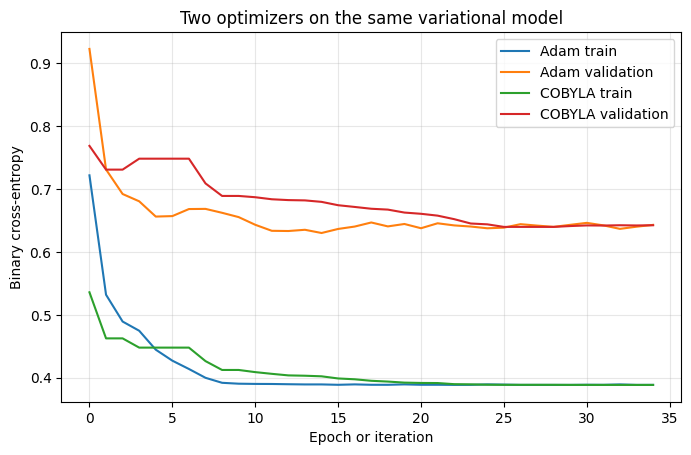

In [10]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_binary_dataset(seed=12)
initial_weights = np.array([0.30, -0.20, 0.10, 0.05], dtype=float)

adam_result = adam_train(
    X_train, y_train, X_val, y_val,
    initial_weights=initial_weights,
    epochs=35,
    batch_size=12,
    learning_rate=0.08,
    seed=23,
)
cobyla_result = cobyla_train(
    X_train, y_train, X_val, y_val,
    initial_weights=initial_weights,
    maxiter=45,
    rhobeg=0.5,
    tol=1e-4,
)

adam_test = evaluate_classifier(X_test, y_test, adam_result["weights"])
cobyla_test = evaluate_classifier(X_test, y_test, cobyla_result["weights"])

print("Adam final weights:", adam_result["weights"])
print("Adam final train BCE:", adam_result["train_history"][-1])
print("Adam final validation BCE:", adam_result["val_history"][-1])
print("Adam test BCE:", adam_test["bce"])
print("Adam test accuracy:", adam_test["accuracy"])
print()
print("COBYLA final weights:", cobyla_result["weights"])
print("COBYLA final train BCE:", cobyla_result["train_history"][-1])
print("COBYLA final validation BCE:", cobyla_result["val_history"][-1])
print("COBYLA test BCE:", cobyla_test["bce"])
print("COBYLA test accuracy:", cobyla_test["accuracy"])

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(adam_result["train_history"], label="Adam train")
ax.plot(adam_result["val_history"], label="Adam validation")
ax.plot(cobyla_result["train_history"], label="COBYLA train")
ax.plot(cobyla_result["val_history"], label="COBYLA validation")
ax.set_xlabel("Epoch or iteration")
ax.set_ylabel("Binary cross-entropy")
ax.set_title("Two optimizers on the same variational model")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


The point of this comparison is not to declare a universal winner, but to read the tradeoffs. Adam uses parameter-shift gradients and therefore makes a gradient-informed update after every mini-batch. COBYLA uses only objective values and can still reduce the loss, but the interpretation of one “iteration” is different because the optimizer internally decides which trial points to evaluate. That is why fair comparisons in QML should track not only the final loss, but also evaluation budgets, shot budgets, and initialization sensitivity.


### Task 3 (coding): How sensitive are Adam and COBYLA to the initialization?

Reuse the optimizer helpers and compare the three initializations below on the same train/validation/test split:

```python
initializations = {
    "A": np.array([0.30, -0.20, 0.10, 0.05]),
    "B": np.array([-0.40, 0.15, 0.60, -0.10]),
    "C": np.array([0.80, -0.60, 0.20, 0.30]),
}
```

Write a reusable function that runs both optimizers from the same starting point and returns, for each optimizer, the final validation loss, the best validation loss reached during training, the test BCE, the test accuracy, and the number of recorded updates. Use it on all three initializations, organize the results in a compact structure, and produce a plot that compares the best validation loss obtained by Adam and COBYLA across the three starts. Conclude with a short paragraph about what these runs suggest regarding optimizer stability and the role of initialization.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="02-gradients-and-optimizers-in-qml-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [11]:
# Task 3 starter
X_train, X_val, X_test, y_train, y_val, y_test = prepare_binary_dataset(seed=12)
initializations = {
    "A": np.array([0.30, -0.20, 0.10, 0.05]),
    "B": np.array([-0.40, 0.15, 0.60, -0.10]),
    "C": np.array([0.80, -0.60, 0.20, 0.30]),
}

# TODO:
# 1. write one helper that runs Adam and COBYLA from the same initialization
# 2. extract final validation loss, best validation loss, test BCE, test accuracy, and update count
# 3. call that helper on all three initializations
# 4. organize the summaries in a compact dictionary or list of rows
# 5. plot the best validation loss for Adam and COBYLA across initializations
# 6. summarize what the experiment suggests about optimizer stability


## Other optimizers worth knowing

Adam and COBYLA are only two points in a much larger optimizer landscape. In practice, the choice of optimizer depends on whether explicit gradients are available, how noisy the objective evaluations are, how expensive circuit calls become under finite shots, and how strongly one wants to exploit problem structure. The list below is only a small sample.

- [Gradient descent](https://en.wikipedia.org/wiki/Gradient_descent): the basic first-order update rule. Implementations: Qiskit [`GradientDescent`](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.optimizers.GradientDescent.html), PennyLane [`qml.GradientDescentOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html).
- [SPSA](https://en.wikipedia.org/wiki/Simultaneous_perturbation_stochastic_approximation): a stochastic optimization method that estimates gradient information from very few objective evaluations per step, which can be attractive under shot noise. Implementations: Qiskit [`SPSA`](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.optimizers.SPSA.html), PennyLane [`qml.SPSAOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.SPSAOptimizer.html).
- [Nelder-Mead](https://en.wikipedia.org/wiki/Nelder%E2%80%93Mead_method): a derivative-free simplex method. Implementation: Qiskit [`NELDER_MEAD`](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.optimizers.NELDER_MEAD.html).
- [L-BFGS-B](https://en.wikipedia.org/wiki/Limited-memory_BFGS): a limited-memory quasi-Newton method that uses gradient information while avoiding the full cost of storing a dense Hessian approximation. Implementation: Qiskit [`L_BFGS_B`](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.optimizers.L_BFGS_B.html).
- [Rotosolve and Rotoselect](https://pennylane.ai/qml/demos/tutorial_rotoselect): QML-specific gradient-free strategies that exploit the sinusoidal dependence of many circuit parameters. Implementations: PennyLane [`qml.RotosolveOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.RotosolveOptimizer.html), [`qml.RotoselectOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.RotoselectOptimizer.html).
- [Shot-adaptive optimization](https://docs.pennylane.ai/en/stable/code/api/pennylane.ShotAdaptiveOptimizer.html): a strategy that adapts the shot allocation during training rather than keeping it fixed across parameters and iterations. Implementation: PennyLane [`qml.ShotAdaptiveOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.ShotAdaptiveOptimizer.html).

Different frameworks expose different subsets of optimizers, and not every optimizer is equally natural for every QML task. That is why optimizer comparisons should always report not only the final loss, but also the gradient rule, shot budget, stopping criterion, and evaluation budget used to obtain it.


## Key takeaways

- Gradients in QML are not a separate objective; they are derivatives of the empirical objective already defined by the learning task.
- Finite differences are useful as a baseline, but they introduce a step-size choice and are not exact.
- Parameter shift can yield exact score derivatives for a broad family of variational gates, but its evaluation cost still grows linearly with the number of trainable parameters.
- Shot noise and mini-batch sampling both affect gradient variability, so controlled seeds matter for fair comparisons.
- Optimizer comparisons in QML should be read through losses, accuracies, and resource usage together, not through one metric alone.
